# CMS Open Data W + C-Jet Analysis

This notebook performs a physics analysis to isolate **W boson + Charm (c) Jet** events from the CMS Open Data MC sample with 'W plus 1 jet' final state.

### Physics Context
The production of a W boson in association with a charm quark ($W + c$) is a sensitive probe of the strange quark content in the proton. The dominant leading-order process is **gluon-strange fusion** ($g + s \to W^- + c$ or $g + \bar{s} \to W^+ + \bar{c}$).

### Sample used

Simulated dataset `W1JetsToLNu_TuneCP5_13TeV-madgraphMLM-pythia8` in NANOAODSIM format for 2016 collision data. (42,019,790 events. 62 files. 42.7 GiB in total)
https://opendata.cern.ch/record/69545

### Analysis Strategy
1.  **W Tagging:** We identify the W boson via its leptonic decay ($W \to \mu\nu$). We look for a high-$p_T$, isolated "tight" muon and Missing Transverse Energy ($p_T^{miss}$).
2.  **C Tagging:** Charm jets often contain "soft" leptons from semileptonic decays ($c \to s \mu \nu$). We look for a non-isolated "soft" muon inside a jet.
3.  **OS - SS Subtraction:** The W muon and the soft muon from the c-jet should have **Opposite Signs (OS)**. Backgrounds (like $t\bar{t}$ or Drell-Yan) are often charge-symmetric. By subtracting **Same Sign (SS)** events from OS events, we statistically remove the background to reveal the pure signal.

#### Note: Here, we assume that the "soft" muon from C-jet will be present in the reco muon collection.

## 1. Setup & Imports

We utilize the **Scikit-HEP** stack: `coffea` for event processing, `awkward` for jagged array manipulation, and `mplhep` to give our plots that publication-quality CMS look. 

Also defines helper functions for kinematics (`delta_phi`) and plotting (`plot_with_stats`).

In [351]:
import os
import numpy as np
import awkward as ak
import dask_awkward as dak
import dask
import hist
import hist.dask as dhist
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import matplotlib.pyplot as plt
import mplhep as mh
from matplotlib.offsetbox import AnchoredText
%matplotlib inline


OUTPUT_DIR = "output_notebook"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Plots will be saved to: {os.path.abspath(OUTPUT_DIR)}/")

# CMS Style
plt.style.use(mh.style.CMS)
plt.rcParams.update({"font.size": 12})

def delta_phi(phi1, phi2):
    """Computes delta phi, handling the wrapping at pi."""
    dphi = phi1 - phi2
    return (dphi + np.pi) % (2 * np.pi) - np.pi

def save_and_show(fig, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(path, bbox_inches="tight")
    print(f"Saved: {path}")
    plt.show() # Show in notebook
    plt.close(fig)

def plot_with_stats(h_computed, data_computed, label, xlabel, filename, logy=False, color="black"):
    """
    Plots a histogram with a CMS-style statistics box (Entries, Mean, Std Dev).
    """
    # Calculate Stats
    n_entries = len(data_computed)
    if n_entries > 0:
        mean_val = np.mean(data_computed)
        std_val = np.std(data_computed)
    else:
        mean_val = 0; std_val = 0

    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    
    # Plot Histogram
    mh.histplot(h_computed, ax=ax, label=label, yerr=False, histtype="step", linewidth=2, color=color)
    mh.cms.label("Open Data", data=True, lumi=None, com=13, year=2016, loc=0)

    # Create Stats Box
    stat_text = (f"Entries: {n_entries}\n"
                 f"Mean:    {mean_val:.2f}\n"
                 f"Std Dev: {std_val:.2f}")
    
    at = AnchoredText(stat_text, prop=dict(size=10), frameon=True, loc='upper right')
    ax.add_artist(at)

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Events")
    ax.legend(loc='upper left')

    if logy: ax.set_yscale("log")
    
    save_and_show(fig, filename)

Plots will be saved to: /Users/sbakare/work/OpenData_CharmTaggingAnalysis/Wc_Analysis/output_notebook/


## 2. Load Data

We load the `W1JetsToLNu` sample of simulated $W \to L\nu$ events. We use `dask` mode, which allows us to define operations lazily—data is only read from the disk when we actually ask for a plot or a count.

In [352]:
fname = "./datasets/nano106X_on_mini106X_2017_mc_NANOAOD_W1Jets_to_LNu_250K.root"
print(f"Loading: {fname}")

events = NanoEventsFactory.from_root(
    {fname: "Events"},
    schemaclass=NanoAODSchema,
    metadata={"dataset": "WJets"},
    mode="dask"
).events()

hists_to_compute = {}   # The histograms
stats_to_compute = {}   # The raw arrays (for Mean/Std calc)
counters = {}           # The Cutflow numbers

# --- CUTFLOW 1: INITIAL ---
counters["1. Sample size"] = dak.num(events, axis=0)

Loading: ./datasets/nano106X_on_mini106X_2017_mc_NANOAOD_W1Jets_to_LNu_250K.root


/Users/sbakare/miniconda3/envs/psi/lib/python3.14/site-packages/coffea/nanoevents/schemas/nanoaod.py:283: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/Users/sbakare/miniconda3/envs/psi/lib/python3.14/site-packages/coffea/nanoevents/schemas/nanoaod.py:283: RuntimeWarning: Missing cross-reference index for LowPtElectron_genPartIdx => GenPart
  warnings.warn(
/Users/sbakare/miniconda3/envs/psi/lib/python3.14/site-packages/coffea/nanoevents/schemas/nanoaod.py:283: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(
/Users/sbakare/miniconda3/envs/psi/lib/python3.14/site-packages/coffea/nanoevents/schemas/nanoaod.py:322: RuntimeWarning: Branch Photon_mass already exists but its values will be replaced with 0.0
  warnings.warn(
/Users/sbakare/miniconda3/envs/psi/lib/python3.14/site-packages/coffea/nanoevents/schemas/nanoaod.py:322: RuntimeWarning: Branch Photon_charge already exists b

## 3. Pre-selection

Before identifying complex objects, we filter for events that have enough raw activity to be interesting. Since we are looking for two muons (one high energy from the W, one soft from the C-jet), we filter for events with **at least 2 muons**.

### Physics Objects & Raw Plots
Here we define Muons, Jets, and MET. We calculate the Transverse Mass ($M_T$) for all muons to visualize the W-boson peak before applying cuts.

In [353]:
print("Defining Physics Objects...")

muons = events.Muon
jets = events.Jet
met = events.MET

# Transverse Mass (Mt) for ALL muons
dphi_w = delta_phi(muons.phi, met.phi)
mt_w = np.sqrt(2 * muons.pt * met.pt * (1 - np.cos(dphi_w)))

hists_to_compute["nJet"] = dhist.Hist(hist.axis.Regular(16, 0, 16, name="nJet")).fill(dak.num(jets, axis=1))
stats_to_compute["nJet"] = dak.num(jets, axis=1)

hists_to_compute["Jet_pt"] = dhist.Hist(hist.axis.Regular(50, 0, 150, name="Cjet_pt")).fill(dak.flatten(jets.pt))
stats_to_compute["Jet_pt"] = dak.flatten(jets.pt)

nMu_raw = dak.num(muons, axis=1)
hists_to_compute["0nMu"] = dhist.Hist(hist.axis.Regular(8, 0, 8, name="0nmu")).fill(nMu_raw)
stats_to_compute["0nMu"] = nMu_raw 

has_2_muon = nMu_raw >= 1
two_muons = muons[has_2_muon]

hists_to_compute["nMu"] = dhist.Hist(hist.axis.Regular(8, 0, 8, name="nmu")).fill(dak.num(two_muons, axis=1))
stats_to_compute["nMu"] = dak.num(two_muons, axis=1)

hists_to_compute["Mu_pt"] = dhist.Hist(hist.axis.Regular(50, 0, 150, name="Wmu_pt")).fill(dak.flatten(two_muons.pt))
stats_to_compute["Mu_pt"] = dak.flatten(two_muons.pt)

hists_to_compute["mt"] = dhist.Hist(hist.axis.Regular(50, 0, 150, name="mt")).fill(dak.flatten(mt_w))
stats_to_compute["mt"] = dak.flatten(mt_w)

Defining Physics Objects...


## 4. W Boson Selection
This muon comes from the direct decay of the W boson. It must be energetic and isolated (not surrounded by other particles). We also check the Transverse Mass ($M_T$) of the Muon+MET system to ensure it looks like a W boson ($M_T > 50$ GeV).

In [354]:
print("Defining W Selection...")

# W Selection Cuts
w_muon_mask = (
    (muons.pt > 30) &        
    (abs(muons.eta) < 2.4) & 
    (muons.tightId) &             
    (muons.pfRelIso04_all < 0.15) &
    (mt_w > 50)                   
)
W_Muons = muons[w_muon_mask]

# --- CUTFLOW 2: W BOSON ---
nW = dak.num(W_Muons, axis=1)
has_w = nW >= 1
counters["2. W_Mu cuts"] = dak.sum(has_w)

#Muons passing W Cut
hists_to_compute["W-cut_nMu"] = dhist.Hist(hist.axis.Regular(8, 0, 8, name="nW")).fill(nW[has_w])
stats_to_compute["W-cut_nMu"] = nW[has_w]

Defining W Selection...


## 5. Charm Tagging
We identify charm jets by looking for a "Soft Muon" inside a jet. This exploits the semi-leptonic decay $c \to s \mu \nu$ (BR ~10%).

### The "Soft" (Charm) Muon
This muon comes from inside a jet (part of a b or c hadron decay).
* **Low $p_T$:** It carries only a fraction of the jet energy.
* **Non-Isolated:** It is buried inside the jet cone (`pfRelIso04_all > 0.2`).
* **Jet Associated:** It must be linked to a jet (`jetIdx >= 0`).

In [355]:
print("Defining Charm Selection...")

# Soft Muon Cuts 
soft_muon_mask = (
    (muons.pt < 20) &             
    (abs(muons.eta) < 2.4) &
    # (muons.tightId) &
    (muons.pfRelIso04_all > 0.2) &
    # (abs(muons.dxy/muons.dxyErr) > 2.0) &
    # (muons.sip3d > 2.0) &
    (muons.jetIdx >= 0)           
)

sip2d_values = (abs(muons.dxy / muons.dxyErr))[soft_muon_mask]

hists_to_compute["sip2d"] = dhist.Hist(
    hist.axis.Regular(50, 0, 10, name="sip2d", label="Muon 2D Impact Param Sig")
).fill(dak.flatten(sip2d_values))
stats_to_compute["sip2d"] = dak.flatten(sip2d_values)

hists_to_compute["sip3d"] = dhist.Hist(
    hist.axis.Regular(50, 0, 20, name="sip3d", label="Muon 3D Impact Param Sig")
).fill(dak.flatten(muons.sip3d[soft_muon_mask]))
stats_to_compute["sip3d"] = dak.flatten(muons.sip3d[soft_muon_mask])

hists_to_compute["muons.dxy"] = dhist.Hist(
    hist.axis.Regular(50, -0.1, 0.1, name="dxy", label="Muon dxy [cm]")
).fill(dak.flatten(muons.dxy[soft_muon_mask]))
stats_to_compute["muons.dxy"] = dak.flatten(muons.dxy[soft_muon_mask])

hists_to_compute["muons.dxyErr"] = dhist.Hist(
    hist.axis.Regular(50, 0, 0.02, name="dxyErr", label="Muon dxy Error [cm]")
).fill(dak.flatten(muons.dxyErr[soft_muon_mask]))
stats_to_compute["muons.dxyErr"] = dak.flatten(muons.dxyErr[soft_muon_mask])

soft_muon_mask = soft_muon_mask & (muons.sip3d > 2.0)
Soft_Muons = muons[soft_muon_mask]
Matched_Jets = jets[Soft_Muons.jetIdx]

# C-Jet Kinematic Cuts
c_jet_mask = (Matched_Jets.pt > 30) & (abs(Matched_Jets.eta) < 2.4)
Good_C_Jets = Matched_Jets[c_jet_mask]
Good_Soft_Muons = Soft_Muons[c_jet_mask]

# --- CUTFLOW 3: C TAG ---
nC = dak.num(Good_C_Jets, axis=1)
has_c = nC >= 1
counters["3. Soft C_Mu & Jet cuts"] = dak.sum(has_c)

has_jet = dak.num(Matched_Jets, axis=1) >= 1
# C-Tagging variables
hists_to_compute["Matched_Jets"] = dhist.Hist(hist.axis.Regular(8, 0, 8, name="Matched_Jets")).fill(dak.num(Matched_Jets, axis=1)[has_jet])
stats_to_compute["Matched_Jets"] = dak.num(Matched_Jets, axis=1)[has_jet]

hists_to_compute["C-cut_nC"] = dhist.Hist(hist.axis.Regular(8, 0, 8, name="nC")).fill(nC[has_c])
stats_to_compute["C-cut_nC"] = nC[has_c]

hists_to_compute["softMu_pt"] = dhist.Hist(hist.axis.Regular(20, 0, 25, name="pt")).fill(dak.flatten(Good_Soft_Muons.pt[has_c]))
stats_to_compute["softMu_pt"] = dak.flatten(Good_Soft_Muons.pt[has_c])

hists_to_compute["c_pt"] = dhist.Hist(hist.axis.Regular(50, 30, 200, name="pt")).fill(dak.flatten(Good_C_Jets.pt[has_c]))
stats_to_compute["c_pt"] = dak.flatten(Good_C_Jets.pt[has_c])

Defining Charm Selection...


## 6. Signal Region & Charge Correlation

We require exactly one valid W candidate (to avoid $Z \to \mu\mu$ or $t\bar{t}$ dilepton backgrounds) and at least one C-Jet candidate.

We then separate them into **Opposite Sign (OS)** (Signal + Background) and **Same Sign (SS)** (Background Only).

In [356]:
print("Defining Signal Region...")

event_mask = (nW == 1) & (nC >= 1)

# --- CUTFLOW 4: SIGNAL REGION ---
counters["4. Signal Region"] = dak.sum(event_mask)

Final_W = W_Muons[event_mask]
Final_C = Good_C_Jets[event_mask]
Final_Soft = Good_Soft_Muons[event_mask]

# OS / SS Logic
w_charge = Final_W.charge[:, 0]
soft_charge = Final_Soft.charge

# Broadcast W charge to match number of soft muons 
w_charge_broadcast = dak.broadcast_arrays(w_charge, soft_charge)[0]

is_OS = w_charge_broadcast != soft_charge
is_SS = w_charge_broadcast == soft_charge

# Final Physics Histograms
axis_final = hist.axis.Regular(15, 30, 150, name="pt", label=r"Charm Jet $p_T$ [GeV]")
h_os = dhist.Hist(axis_final, storage=hist.storage.Weight()).fill(dak.flatten(Final_C[is_OS].pt))
h_ss = dhist.Hist(axis_final, storage=hist.storage.Weight()).fill(dak.flatten(Final_C[is_SS].pt))

Defining Signal Region...


## 7. Computation
This cell runs the Dask graph, computing all histograms and statistics in a single pass over the data.

In [357]:
print("Running Compute (Physics + Stats + Cutflow)...")

# We zip everything into one list to compute efficiently
comp_keys_h = list(hists_to_compute.keys())
comp_vals_h = list(hists_to_compute.values())

comp_keys_s = list(stats_to_compute.keys())
comp_vals_s = list(stats_to_compute.values())

comp_keys_c = list(counters.keys())
comp_vals_c = list(counters.values())

# The Big Compute
results = dask.compute(
    h_os, h_ss,         # 0, 1
    *comp_vals_h,       # Histograms
    *comp_vals_s,       # Raw Arrays (for stats)
    *comp_vals_c        # Counters
)

# Unpack Results
res_os, res_ss = results[0], results[1]

# Unpack Lists using slicing
offset = 2
res_hists = dict(zip(comp_keys_h, results[offset : offset + len(comp_keys_h)]))
offset += len(comp_keys_h)
res_stats = dict(zip(comp_keys_s, results[offset : offset + len(comp_keys_s)]))
offset += len(comp_keys_s)
res_counts = dict(zip(comp_keys_c, results[offset : offset + len(comp_keys_c)]))

print("Computation Complete.")

Running Compute (Physics + Stats + Cutflow)...
Computation Complete.


## 8. Plots
Visualizing the raw data and intermediate steps to ensure cuts are working as expected.

Generating Control Plots...
Saved: output_notebook/01_Raw_nJet.png


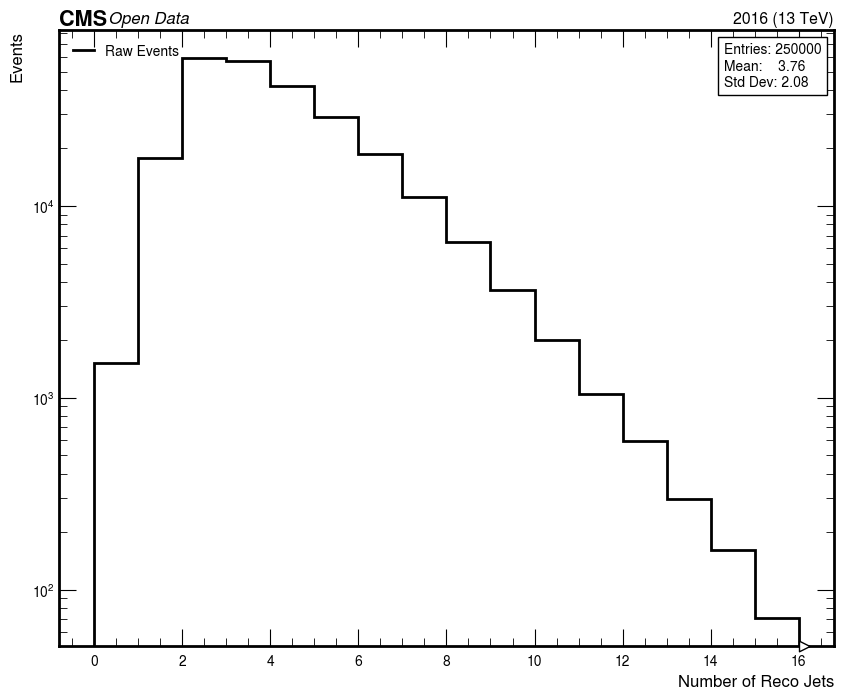

Saved: output_notebook/02_Raw_JetPt.png


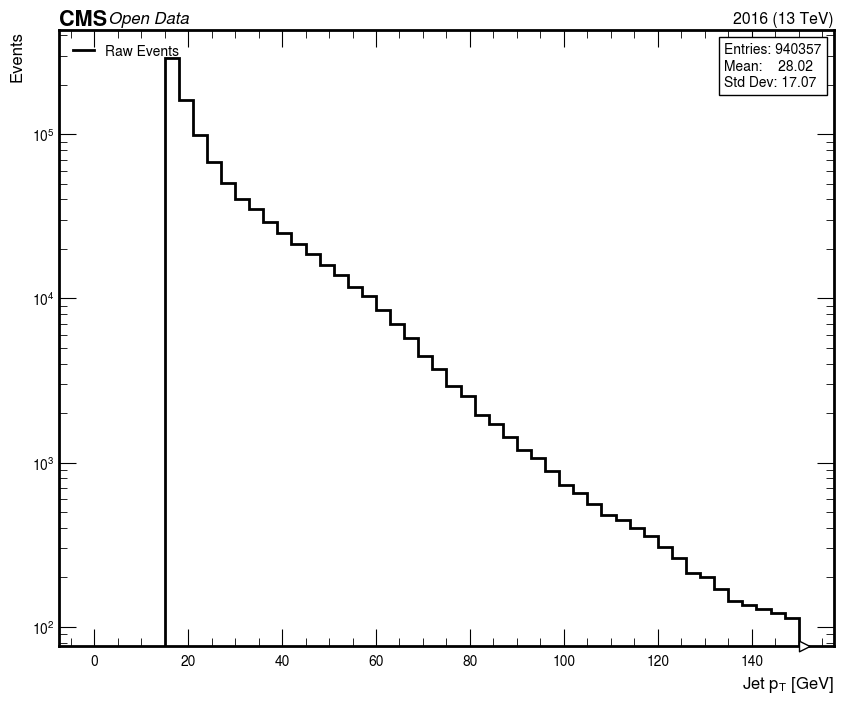

Saved: output_notebook/03_Raw_nMu.png


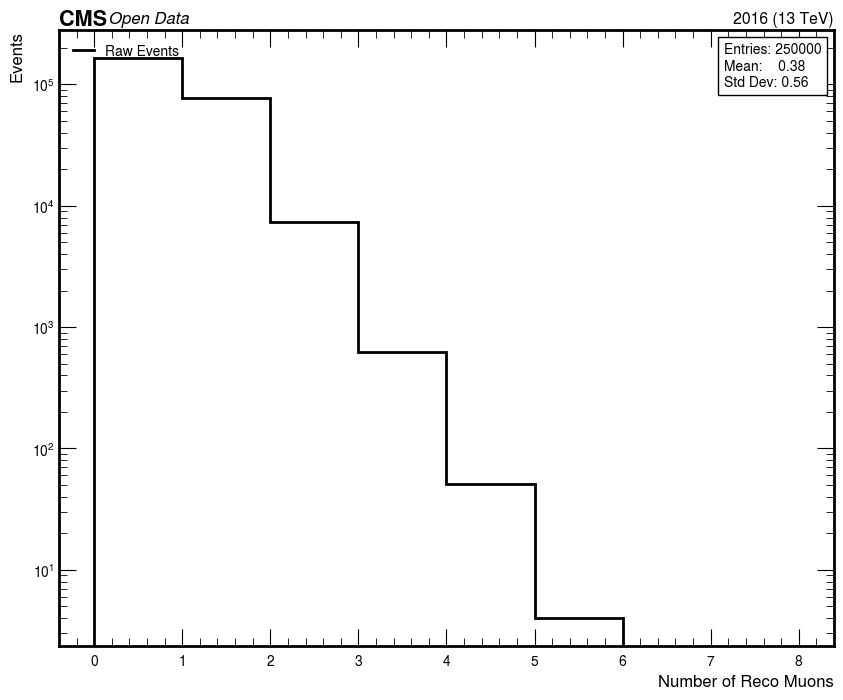

Saved: output_notebook/04_Raw_nMu.png


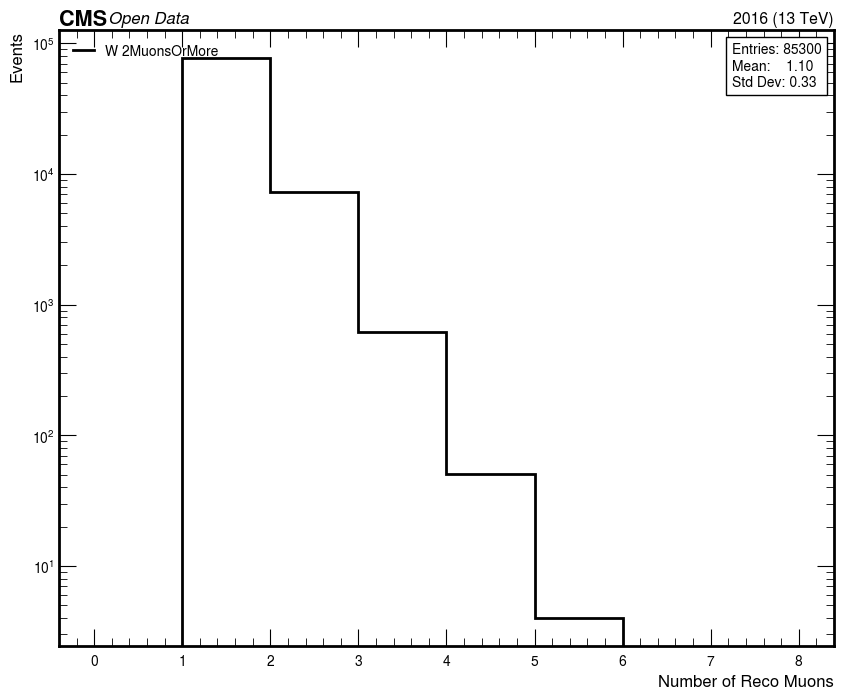

Saved: output_notebook/05_Raw_MuPt.png


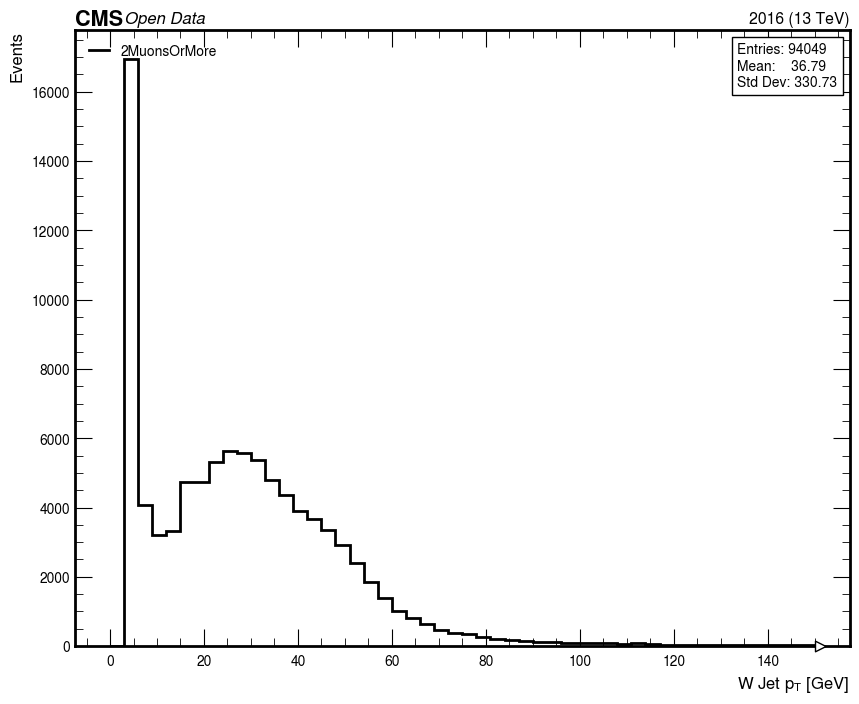

Saved: output_notebook/06_Raw_mT.png


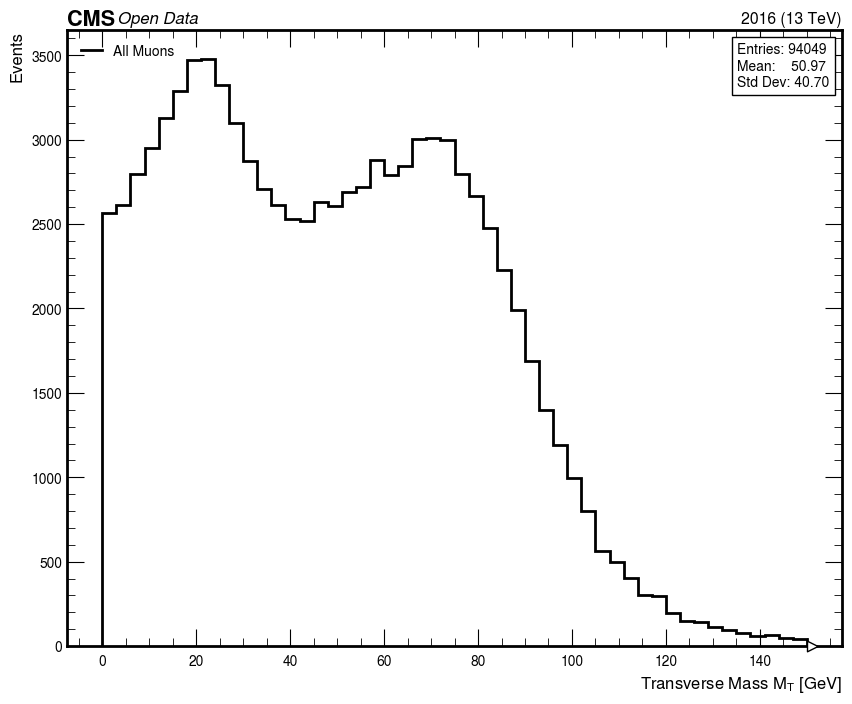

Saved: output_notebook/07_W-cut_nMu.png


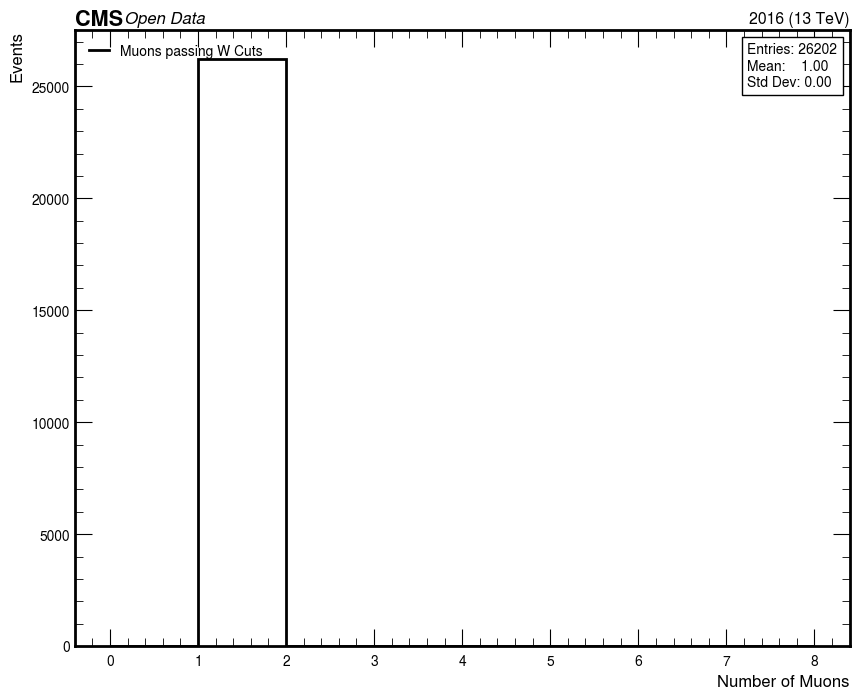

Saved: output_notebook/09_C-cut_SoftMu_pt.png


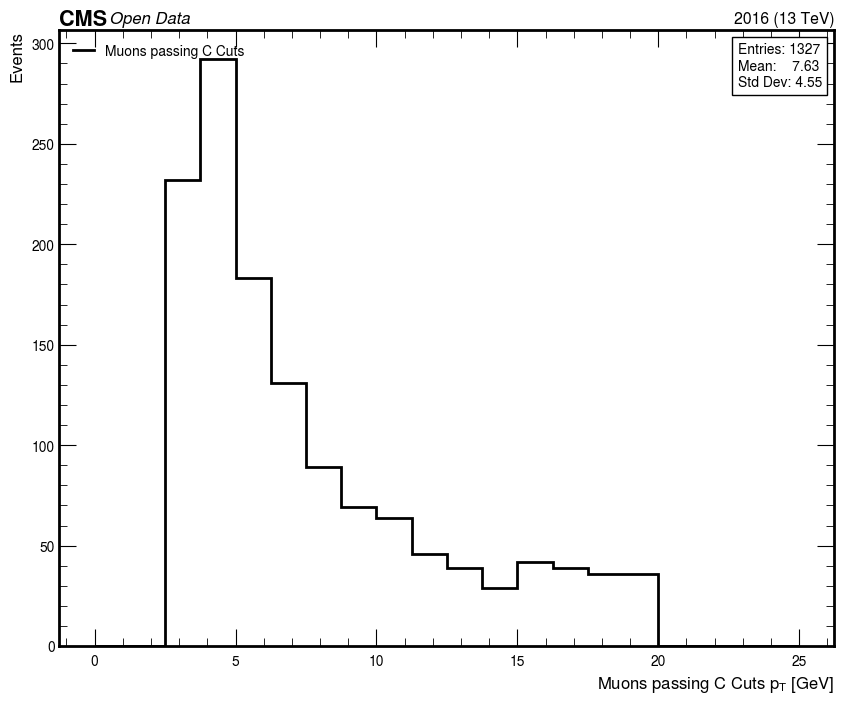

Saved: output_notebook/10_C-cut_CJet_pt.png


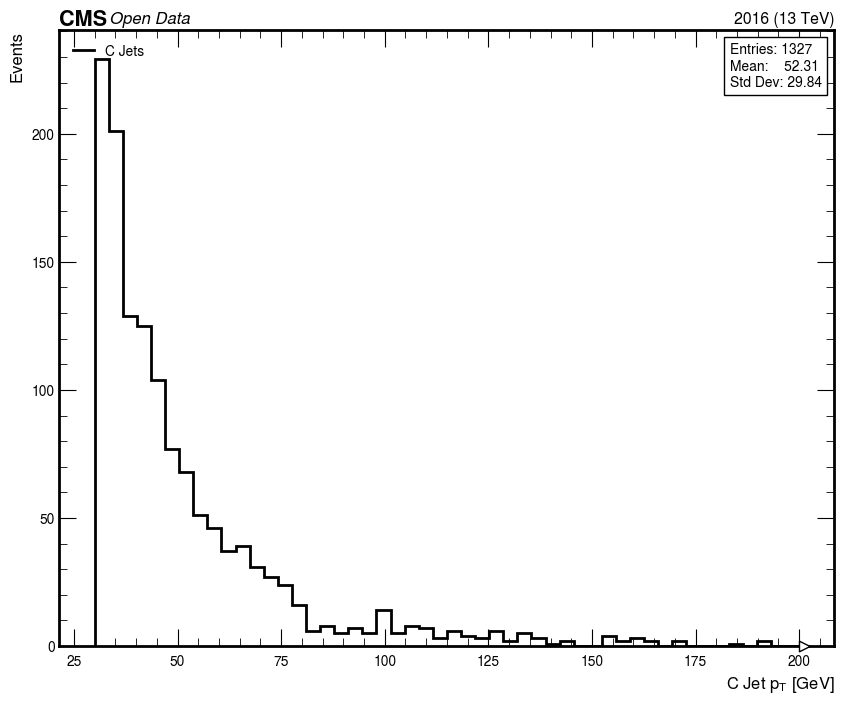

In [358]:
print("Generating Control Plots...")

plot_with_stats(res_hists["nJet"], res_stats["nJet"], "Raw Events", r"Number of Reco Jets", "01_Raw_nJet.png", logy=True)
plot_with_stats(res_hists["Jet_pt"], res_stats["Jet_pt"], "Raw Events", r"Jet $p_T$ [GeV]", "02_Raw_JetPt.png", logy=True)
plot_with_stats(res_hists["0nMu"], res_stats["0nMu"], "Raw Events", "Number of Reco Muons", "03_Raw_nMu.png", logy=True)
plot_with_stats(res_hists["nMu"], res_stats["nMu"], "W 2MuonsOrMore", "Number of Reco Muons", "04_Raw_nMu.png", logy=True)
plot_with_stats(res_hists["Mu_pt"], res_stats["Mu_pt"],"2MuonsOrMore", r"W Jet $p_T$ [GeV]", "05_Raw_MuPt.png")
plot_with_stats(res_hists["mt"], res_stats["mt"], "All Muons", r"Transverse Mass $M_T$ [GeV]", "06_Raw_mT.png")
plot_with_stats(res_hists["W-cut_nMu"], res_stats["W-cut_nMu"], "Muons passing W Cuts", r"Number of Muons", "07_W-cut_nMu.png")
plot_with_stats(res_hists["softMu_pt"], res_stats["softMu_pt"], "Muons passing C Cuts", r"Muons passing C Cuts $p_T$ [GeV]", "09_C-cut_SoftMu_pt.png")
plot_with_stats(res_hists["c_pt"], res_stats["c_pt"], "C Jets", r"C Jet $p_T$ [GeV]", "10_C-cut_CJet_pt.png")


### Event Yields for 250,000 Generated Events
**Dataset:** `W1JetsToLNu_TuneCP5_13TeV-madgraphMLM-pythia8`

| Cut Stage | Reduction Factor | Exp. Events (per 250k) | Justification |
| :--- | :--- | :--- | :--- |
| **1. Total Gen Events** | 1.00 | **250,000** | Initial Sample Size |
| **2. W Decay ($W \to \mu\nu$)** | 0.33 | **~83,333** | Lepton Universality ($e:\mu:\tau = 1:1:1$) |
| **3. W Selection** | ~0.31 | **~26,202** | Detector Acceptance ($abs(\eta)<2.4$), Trigger Threshold ($p_T>30$), and Tight ID/Iso (<0.15) **Here $p_T>30$ is killing half of the W (only 39,743/83,333 pass)** |
| **4. Charm Jet Fraction** | ~0.12 | **~30,000** | Fraction of W+Jets events containing a $c$-quark (dominated by $g+s \to W+c$). |
| **5. Charm Tagging ($c \to \mu$)** | ~0.0425 | **~1300** | **The Bottleneck**: <br>1. $BR(c \to \mu) \approx 9.6\%$ <br>2. Soft Muon Reco Efficiency $\approx 45\%$ **Here Jet Kinematic Cuts is strongest (only 1300/8959 soft mu pass)**|


### Final Signal Composition
After all cuts, the theoretically expected sample (approx 300 events) will consist of:
* **Signal (OS)**: Events where $Charge(\mu_W) \neq Charge(\mu_{jet})$. This is the $W+c$ signal. 
* **Background (OS+SS)**: Events from $W+b\bar{b}$ (top) or gluon splitting $g \to c\bar{c}$. These produce OS and SS events equally.
* **Analysis Strategy**: Perform `N(OS) - N(SS)` to remove the background and isolate the pure $W+c$ signal count. 

Saved: output_notebook/08_C-cut_sip2d.png


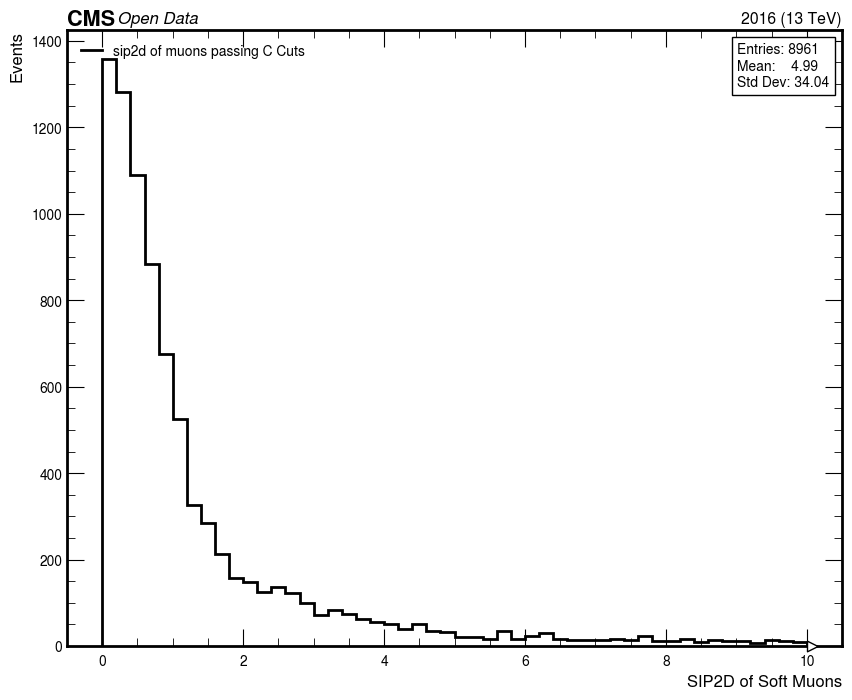

Saved: output_notebook/08_C-cut_sip3d.png


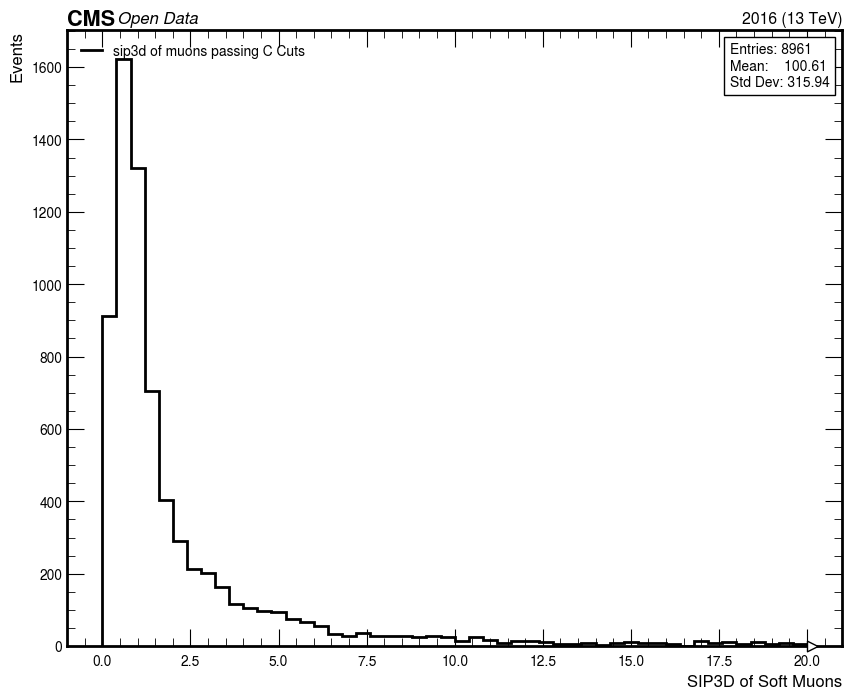

Saved: output_notebook/08_C-cut_dxy.png


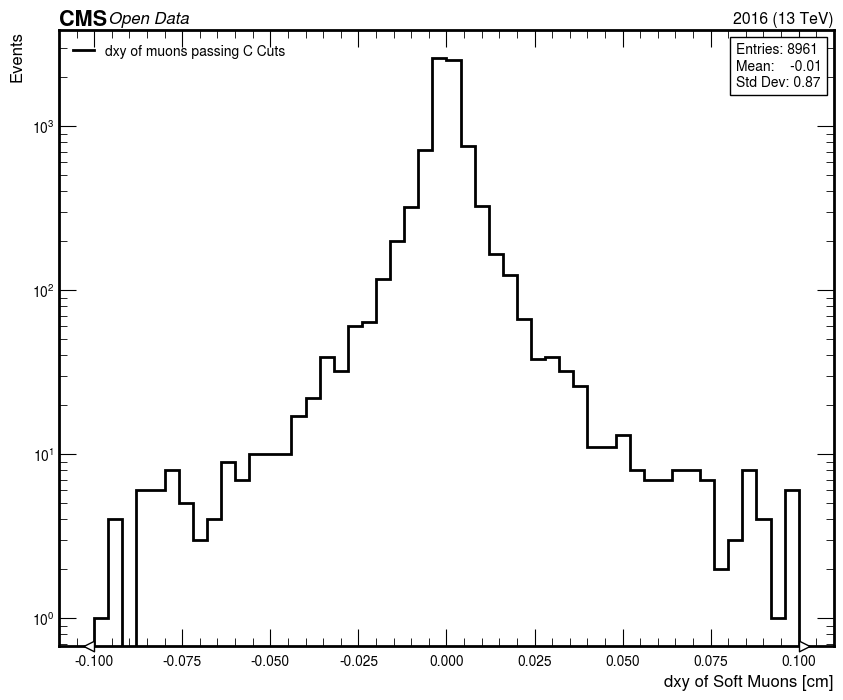

Saved: output_notebook/08_C-cut_dxyErr.png


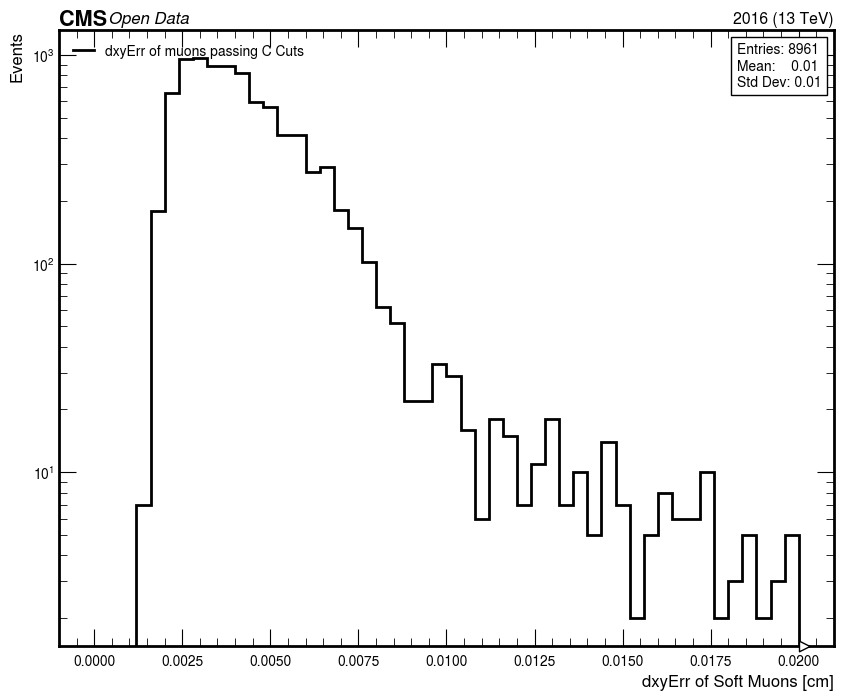

Saved: output_notebook/11_Matched_Jets.png


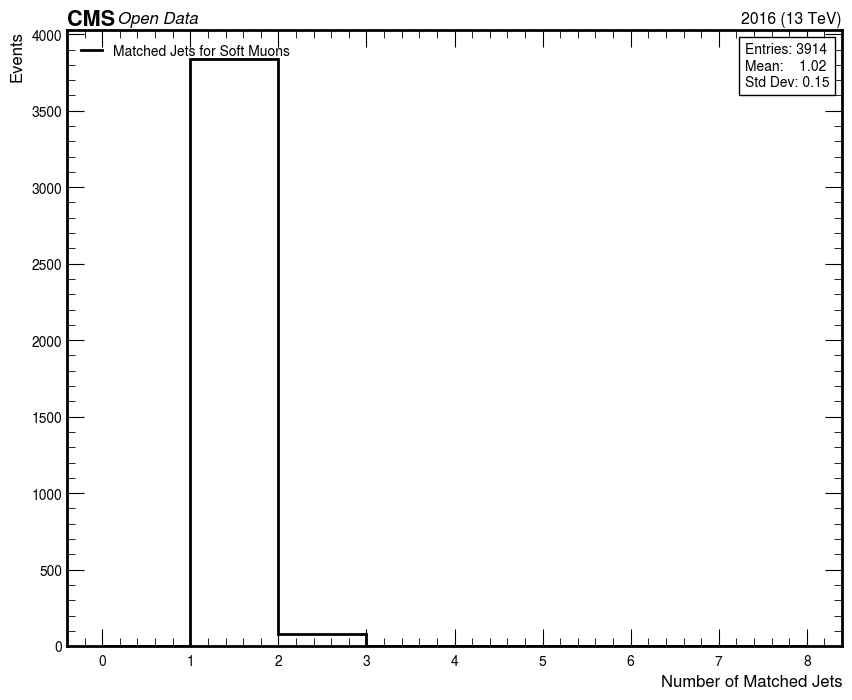

In [359]:
plot_with_stats(res_hists["sip2d"], res_stats["sip2d"], "sip2d of muons passing C Cuts", r"SIP2D of Soft Muons", "08_C-cut_sip2d.png")
plot_with_stats(res_hists["sip3d"], res_stats["sip3d"], "sip3d of muons passing C Cuts", r"SIP3D of Soft Muons", "08_C-cut_sip3d.png")
plot_with_stats(res_hists["muons.dxy"], res_stats["muons.dxy"], "dxy of muons passing C Cuts", r"dxy of Soft Muons [cm]", "08_C-cut_dxy.png", logy=True)
plot_with_stats(res_hists["muons.dxyErr"], res_stats["muons.dxyErr"], "dxyErr of muons passing C Cuts", r"dxyErr of Soft Muons [cm]", "08_C-cut_dxyErr.png", logy=True) 
plot_with_stats(res_hists["Matched_Jets"], res_stats["Matched_Jets"], "Matched Jets for Soft Muons", r"Number of Matched Jets", "11_Matched_Jets.png")

# 9. Event Selection Efficiency
A visual "Cutflow" showing how many events survive each stage of the analysis.

Saved: output_notebook/00_Analysis_Cutflow.png


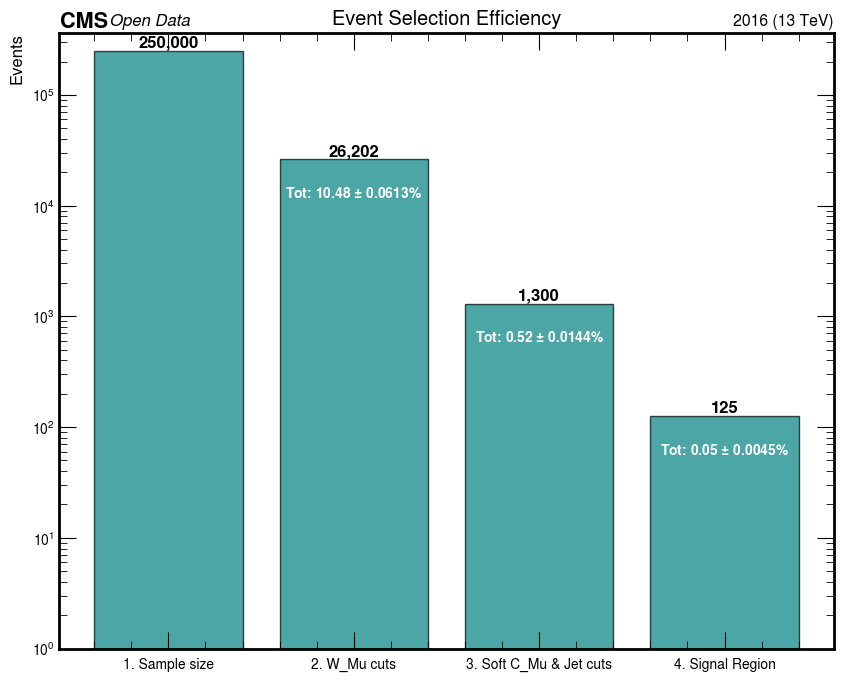


=== CUTFLOW SUMMARY ===
1. Sample size      : 250,000
2. W_Mu cuts        : 26,202
3. Soft C_Mu & Jet cuts: 1,300
4. Signal Region    : 125


In [360]:
def plot_cutflow(counts_dict):
    fig, ax = plt.subplots(figsize=(10, 8))
    labels = list(counts_dict.keys())
    values = list(counts_dict.values())
    
    bars = ax.bar(labels, values, color='teal', alpha=0.7, edgecolor='black')
    initial = values[0]
    
    for i, (bar, val) in enumerate(zip(bars, values)):
        ax.text(bar.get_x() + bar.get_width()/2, val, f"{int(val):,}", 
                ha='center', va='bottom', fontweight='bold')
        if i > 0:
            # 1. Calculate Efficiency (0 to 1 scale first)
            eff = val / initial
            
            # 2. Calculate Binomial Error: sqrt(p(1-p)/N)
            # limit error to avoid math domain errors if eff=0 or 1
            if initial > 0:
                eff_err = np.sqrt(eff * (1 - eff) / initial)
            else:
                eff_err = 0

            # 3. Convert both to Percentages
            # eff_step = (val / values[i-1]) * 100
            eff_pct = eff * 100
            err_pct = eff_err * 100
            text_y = val / 2 if val > 0 else 0
            label = f"Tot: {eff_pct:.2f} $\\pm$ {err_pct:.4f}%"
            ax.text(bar.get_x() + bar.get_width()/2, text_y, label,
                   #f"#Step: {eff_step:.1f}%\nTot: {eff:.2f}%",
                   ha='center', va='center', color='white', fontweight='bold', fontsize=10)

    ax.set_yscale('log')
    ax.set_ylim(bottom=1)
    ax.set_ylabel("Events")
    ax.set_title("Event Selection Efficiency")
    mh.cms.label("Open Data", data=True, lumi=None, com=13, year=2016, loc=0)
    save_and_show(fig, "00_Analysis_Cutflow.png")
    
    print("\n=== CUTFLOW SUMMARY ===")
    for k, v in counts_dict.items():
        print(f"{k:20s}: {int(v):,}")

plot_cutflow(res_counts)

# 10. OS-SS
We subtract the SS background from the OS region to isolate the pure $W+c$ signal.

1.  **Opposite Sign (OS):** The W muon and the Soft muon have opposite charges ($Q_{\mu,W} \neq Q_{\mu,soft}$). This region contains our signal ($g s \to W c$).
2.  **Same Sign (SS):** The muons have the same charge. This region is dominated by background.
3.  **Subtraction:** By subtracting the SS distribution from the OS distribution, we statistically cancel out the background, leaving the excess caused by real $W+c$ events.

*Note: In the subtraction plot, we handle error propagation manually ($\sigma_{diff} = \sqrt{\sigma_{OS}^2 + \sigma_{SS}^2}$).*

Saved: output_notebook/11_Analysis_OS_vs_SS.png


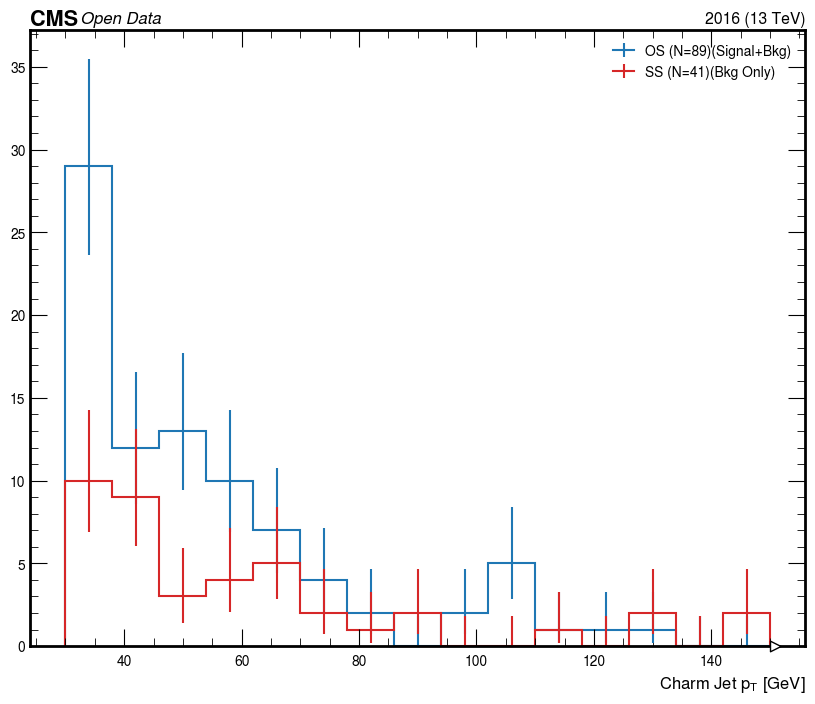

Saved: output_notebook/12_Analysis_Signal_Subtracted.png


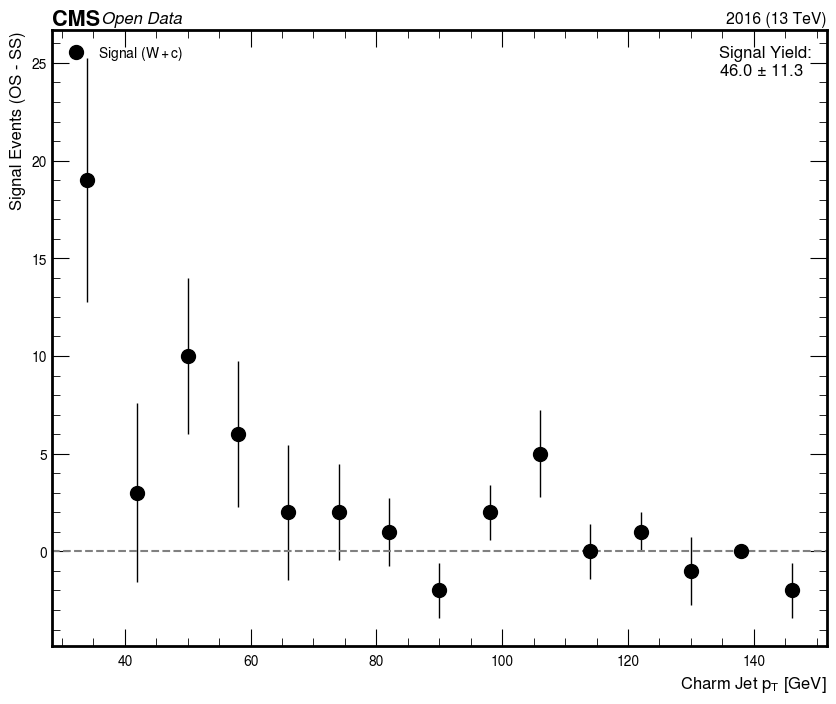

In [361]:
# --- OS vs SS Overlay ---
fig, ax = plt.subplots(figsize=(10, 8))

# Use flow=True to count overflow events (important for full yield)
n_os = res_os.sum(flow=True).value 
n_ss = res_ss.sum(flow=True).value

mh.histplot(res_os, ax=ax, label=f"OS (N={n_os:.0f})(Signal+Bkg)", color="tab:blue")
mh.histplot(res_ss, ax=ax, label=f"SS (N={n_ss:.0f})(Bkg Only)", color="tab:red")
mh.cms.label("Open Data", data=True, lumi=None, com=13, year=2016, loc=0)
ax.legend()
save_and_show(fig, "11_Analysis_OS_vs_SS.png")

# --- Subtracted Signal (OS - SS) ---
y_diff = res_os.values() - res_ss.values()
err_diff = np.sqrt(res_os.variances() + res_ss.variances())
n_sig = np.sum(y_diff)
n_err = np.sqrt(np.sum(res_os.variances() + res_ss.variances()))

fig, ax = plt.subplots(figsize=(10, 8))
mh.histplot(
    y_diff, bins=axis_final.edges, yerr=err_diff,
    ax=ax, label=r"Signal ($W+c$)", color="black", 
    histtype="errorbar", marker='o'
)
ax.axhline(0, color="gray", linestyle="--")
mh.cms.label("Open Data", data=True, lumi=None, com=13, year=2016, loc=0)
ax.set_xlabel(r"Charm Jet $p_T$ [GeV]")
ax.set_ylabel(r"Signal Events (OS - SS)")

# Result Box (using \\pm to fix escape sequence warning)
at = AnchoredText(f"Signal Yield:\n{n_sig:.1f} $\\pm$ {n_err:.1f}", loc="upper right", frameon=False)
ax.add_artist(at)
ax.legend(loc="upper left")

save_and_show(fig, "12_Analysis_Signal_Subtracted.png")